# Notebook 2: Forensic Data Exploration (EDA)
**Objective:** To conduct a rigorous statistical and spatial analysis of the merged PPE dataset (CSS, SHWD, and Pictor-PPE). 

Understanding the distribution of classes, the spatial location of objects, and the variance in bounding box dimensions is critical before training. The insights gathered here will directly inform our data augmentation strategies and YOLO hyperparameter configuration to prevent model bias and improve small-object detection.

### Core Objectives:
1. **Global Class Distribution:** Quantify imbalances across the 5 target classes.
2. **BBox Dimensionality:** Analyze the scale and aspect ratios of the annotations.
3. **Spatial Heatmaps:** Visualize the spatial frequency of objects within the image frame.

In [1]:
# 1.0 Import Libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm.notebook import tqdm
from PIL import Image

# Set plotting style for professional portfolio visuals
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.max_open_warning': 0, 'font.size': 12})

# 1.1 Define Directory Structure
PROJECT_ROOT = Path("../")
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

# Pointing to the training split, as EDA should strictly be performed on training data
# to prevent data leakage from the validation/test sets.
TRAIN_IMG_DIR = PROCESSED_DIR / "images" / "train"
TRAIN_LBL_DIR = PROCESSED_DIR / "labels" / "train"

# 1.2 Define Class Mapping (Inherited from NB01)
CLASS_MAP = {
    0: "hardhat",
    1: "no-hardhat",
    2: "vest",
    3: "no-vest",
    4: "person"
}

# Verify paths
print(f"Targeting Images: {TRAIN_IMG_DIR.resolve()}")
print(f"Targeting Labels: {TRAIN_LBL_DIR.resolve()}")
print(f"Classes loaded: {len(CLASS_MAP)}")

Targeting Images: C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\PPE_Compliance_detection\data\processed\images\train
Targeting Labels: C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\PPE_Compliance_detection\data\processed\labels\train
Classes loaded: 5


### 2. Building the Core DataFrame

To conduct efficient exploratory data analysis, we will parse all YOLO format annotation files (`.txt`) in the training split. Each line in a YOLO label file represents a single bounding box formatted as: `<class_id> <x_center> <y_center> <width> <height>`.

We will extract this data into a Pandas DataFrame, map the numerical class IDs to their human-readable labels, and pre-calculate the bounding box area to analyze object scale later.

In [2]:
# 2.0 Parse YOLO Labels into a DataFrame
bbox_data = []

# Gather all label files in the training split
label_files = list(TRAIN_LBL_DIR.glob("*.txt"))
print(f"Found {len(label_files):,} label files in the training set. Parsing...")

for lbl_path in tqdm(label_files, desc="Extracting Bounding Boxes"):
    if not lbl_path.exists() or lbl_path.stat().st_size == 0:
        continue # Skip empty files safely
        
    with open(lbl_path, "r") as f:
        lines = f.readlines()
        
    for line in lines:
        parts = line.strip().split()
        if len(parts) == 5:
            cls_id = int(parts[0])
            xc, yc, w, h = map(float, parts[1:])
            
            bbox_data.append({
                "image_id": lbl_path.stem,
                "class_id": cls_id,
                "class_name": CLASS_MAP.get(cls_id, f"unknown_{cls_id}"),
                "x_center": xc,
                "y_center": yc,
                "width": w,
                "height": h,
                "area": w * h # Pre-calculate relative area (0.0 to 1.0)
            })

# 2.1 Convert to Pandas DataFrame
df = pd.DataFrame(bbox_data)

print("\n--- DataFrame Construction Complete ---")
print(f"Total bounding boxes extracted: {len(df):,}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
display(df.head())

Found 8,691 label files in the training set. Parsing...


Extracting Bounding Boxes:   0%|          | 0/8691 [00:00<?, ?it/s]


--- DataFrame Construction Complete ---
Total bounding boxes extracted: 115,712
Memory usage: 21.39 MB


,image_id,class_id,class_name,x_center,y_center,width,height,area
0,css_-1079-_png_jpg.rf.19092a3937930012f9fd9c1c...,0,hardhat,0.667188,0.511719,0.045312,0.038281,0.001735
1,css_-1079-_png_jpg.rf.19092a3937930012f9fd9c1c...,0,hardhat,0.096094,0.547656,0.026562,0.019531,0.000519
2,css_-1079-_png_jpg.rf.19092a3937930012f9fd9c1c...,4,person,0.101562,0.625781,0.072656,0.180469,0.013112
3,css_-1079-_png_jpg.rf.19092a3937930012f9fd9c1c...,4,person,0.653125,0.652344,0.111719,0.324219,0.036221
4,css_-1079-_png_jpg.rf.19092a3937930012f9fd9c1c...,4,person,0.813281,0.547656,0.014063,0.033594,0.000472


### 3. Global Class Distribution & Imbalance

In object detection, severe class imbalance can cause the model to overfit to the majority classes (like `person` or `hardhat`) while performing poorly on minority classes (like `no-vest` or `no-hardhat`). 

By visualizing the raw counts and percentage makeup of our training set, we can determine if we need to apply class weights or specific focal loss configurations during YOLO training.

C:\Users\nwagb\AppData\Local\Temp\ipykernel_49636\4235813092.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


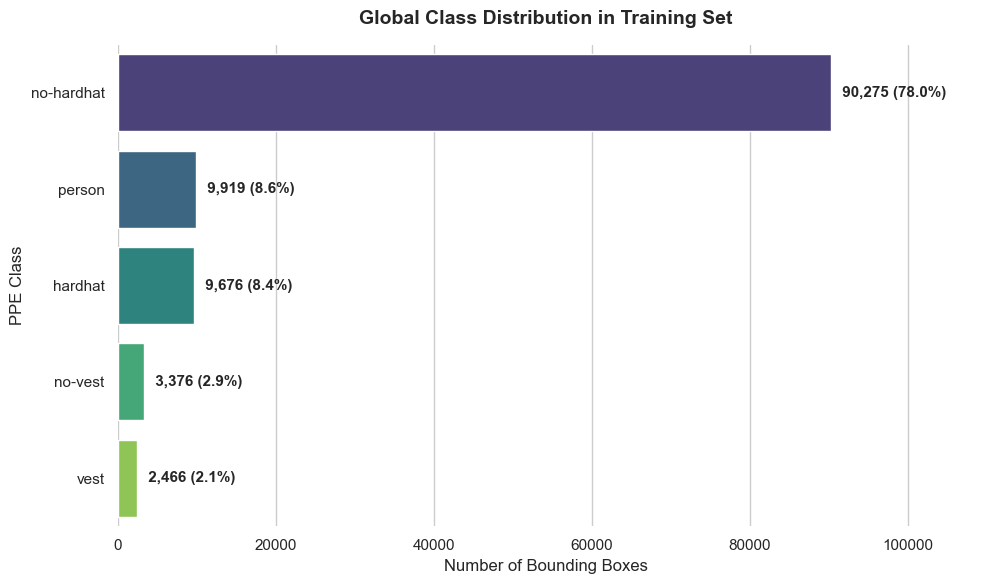

In [3]:
# 3.0 Plotting Class Distribution
plt.figure(figsize=(10, 6))

# Count the occurrences of each class
class_counts = df['class_name'].value_counts()
total_boxes = len(df)

# Create a horizontal bar chart
ax = sns.barplot(
    x=class_counts.values, 
    y=class_counts.index, 
    palette="viridis", 
    orient='h'
)

# Annotate each bar with the exact count and percentage
for i, p in enumerate(ax.patches):
    count = int(p.get_width())
    percentage = (count / total_boxes) * 100
    ax.annotate(
        f" {count:,} ({percentage:.1f}%)", 
        (p.get_width(), p.get_y() + p.get_height() / 2.), 
        va='center', 
        xytext=(5, 0), 
        textcoords='offset points',
        fontsize=11,
        fontweight='bold'
    )

# Format the plot for the portfolio
plt.title('Global Class Distribution in Training Set', fontsize=14, weight='bold', pad=15)
plt.xlabel('Number of Bounding Boxes', fontsize=12)
plt.ylabel('PPE Class', fontsize=12)
plt.xlim(0, class_counts.max() * 1.2) # Add 20% padding to the right so text doesn't cut off
sns.despine(left=True, bottom=True) # Clean up borders
plt.tight_layout()
plt.show()

### 3.1 Train vs. Validation Distribution Check

To ensure our model evaluates fairly during training, the validation set must be a representative sample of the training set. Because the training set is much larger (80%) than the validation set (10%), and test set (10%) comparing raw bounding box counts isn't helpful. 

Instead, we will compare the **normalized percentages** of each class across both splits. If the random split was successful, the proportions of each class should be nearly identical between the `train`, `val`, and `test` sets.

Scanning Validation labels at: C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\PPE_Compliance_detection\data\processed\labels\val...
Scanning Test labels at: C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\PPE_Compliance_detection\data\processed\labels\test...


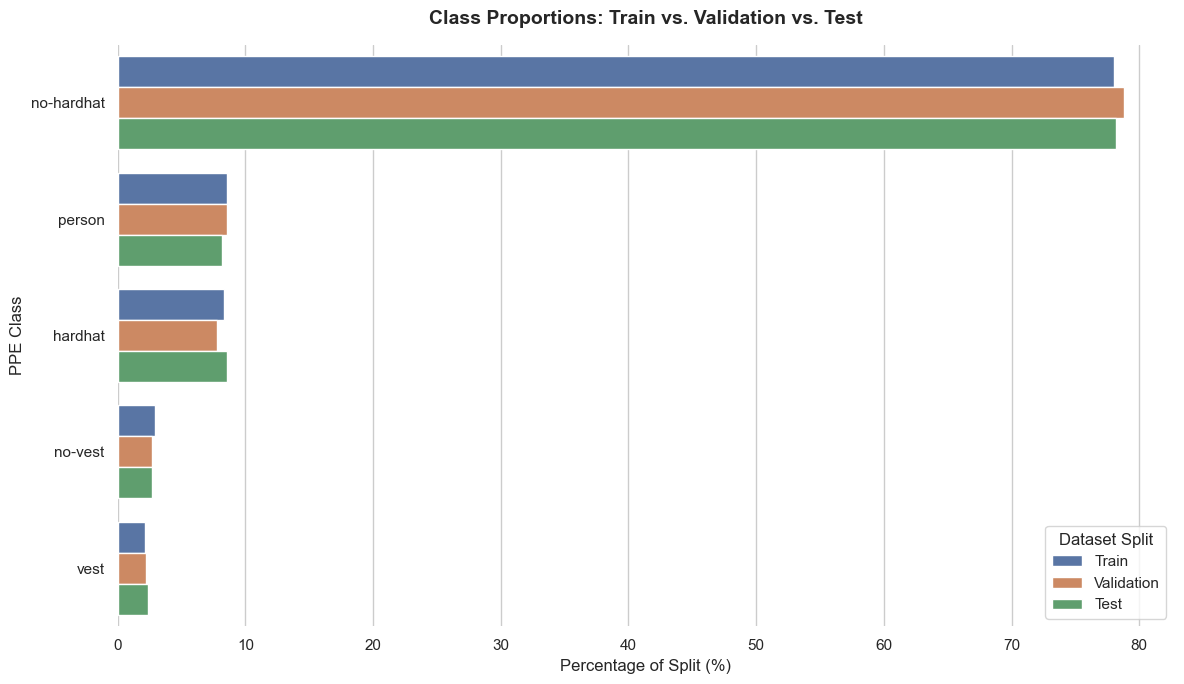

In [5]:
# 3.1 Compare Train vs Val vs Test Distributions
from collections import Counter

# Define validation and test label directories
VAL_LBL_DIR = PROCESSED_DIR / "labels" / "val"
TEST_LBL_DIR = PROCESSED_DIR / "labels" / "test"

def get_class_counts(label_dir, split_name):
    label_files = list(label_dir.glob("*.txt"))
    counts = Counter()
    
    for lbl_path in label_files:
        if not lbl_path.exists() or lbl_path.stat().st_size == 0: 
            continue
        with open(lbl_path, "r") as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 1:
                    cls_id = int(parts[0])
                    counts[CLASS_MAP.get(cls_id, f"unknown_{cls_id}")] += 1
                    
    total_boxes = sum(counts.values())
    if total_boxes == 0:
        return []
        
    return [{"Split": split_name, 
             "Class": k, 
             "Count": v, 
             "Percentage": (v / total_boxes) * 100} 
            for k, v in counts.items()]

print(f"Scanning Validation labels at: {VAL_LBL_DIR.resolve()}...")
print(f"Scanning Test labels at: {TEST_LBL_DIR.resolve()}...")

# We already have the training DataFrame (df) in memory
train_counts = [{"Split": "Train", 
                 "Class": k, 
                 "Count": v, 
                 "Percentage": (v / len(df)) * 100} 
                for k, v in df['class_name'].value_counts().items()]

# Get validation and test counts
val_counts = get_class_counts(VAL_LBL_DIR, "Validation")
test_counts = get_class_counts(TEST_LBL_DIR, "Test")

# Combine into a single DataFrame
dist_df = pd.DataFrame(train_counts + val_counts + test_counts)

# Plotting the side-by-side comparison
plt.figure(figsize=(12, 7))
sns.barplot(
    data=dist_df, 
    x='Percentage', 
    y='Class', 
    hue='Split', 
    palette=["#4c72b0", "#dd8452", "#55a868"] # Added a nice green for the Test split
)

plt.title('Class Proportions: Train vs. Validation vs. Test', fontsize=14, weight='bold', pad=15)
plt.xlabel('Percentage of Split (%)', fontsize=12)
plt.ylabel('PPE Class', fontsize=12)
plt.legend(title='Dataset Split', loc='lower right')
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

### 4. Spatial Distribution (Heatmaps)

Understanding *where* objects are located within the camera frame is critical for evaluating dataset bias. If our bounding boxes are heavily concentrated in the center of the images, the YOLO model may struggle to detect objects near the edges or corners during real-world inference.

Here, we plot the normalized `(x_center, y_center)` coordinates of all 115,000+ bounding boxes. We will generate two views:
1. **Global Heatmap:** A 2D histogram showing the absolute density of all objects.
2. **Class-Specific Zones:** A KDE (Kernel Density Estimate) contour plot separating `hardhat` locations from `vest` locations to see if their spatial distributions logically differ (e.g., hats appearing higher in the frame than vests).

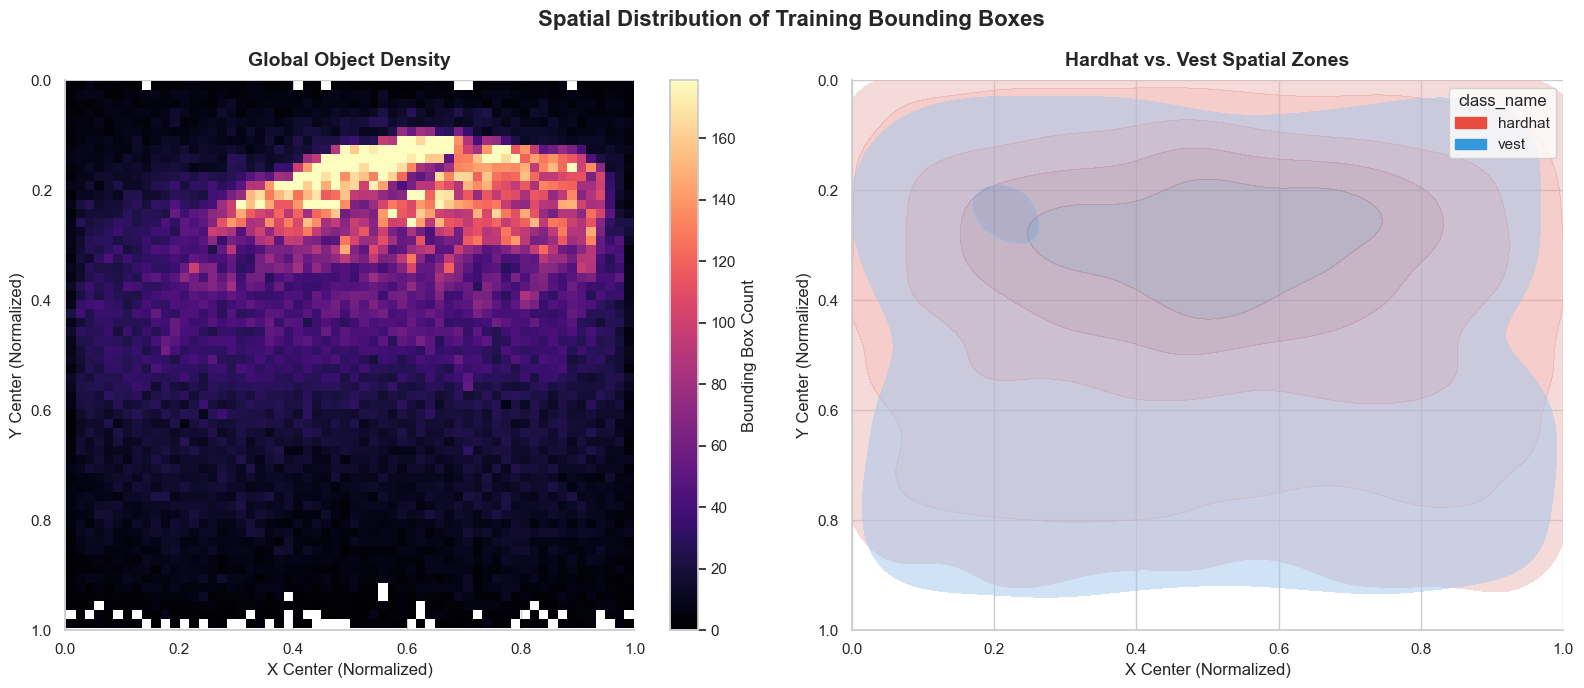

In [6]:
# 4.0 Spatial Distribution (Heatmaps)
# Create a 1x2 grid for our spatial visualizations
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Note: In image processing, the origin (0,0) is the top-left corner. 
# We will invert the Y-axis so the plots visually match how we look at photos.

# --- Plot 1: Global 2D Histogram ---
sns.histplot(
    data=df, 
    x='x_center', 
    y='y_center', 
    bins=60, 
    pmax=0.9, # Cap the max color intensity to reveal more subtle edge details
    cmap="magma", 
    cbar=True, 
    cbar_kws={'label': 'Bounding Box Count'},
    ax=axes[0]
)
axes[0].set_title("Global Object Density", fontsize=14, weight='bold', pad=10)
axes[0].set_xlabel("X Center (Normalized)")
axes[0].set_ylabel("Y Center (Normalized)")
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)
axes[0].invert_yaxis() 

# --- Plot 2: Class-Specific Zones (Hats vs. Vests) ---
# Filter the dataframe for just the target classes
hv_df = df[df['class_id'].isin([0, 2])] 

sns.kdeplot(
    data=hv_df, 
    x='x_center', 
    y='y_center', 
    hue='class_name', 
    fill=True, 
    alpha=0.5, 
    levels=6, # Number of contour rings
    palette={"hardhat": "#e74c3c", "vest": "#3498db"},
    ax=axes[1]
)
axes[1].set_title("Hardhat vs. Vest Spatial Zones", fontsize=14, weight='bold', pad=10)
axes[1].set_xlabel("X Center (Normalized)")
axes[1].set_ylabel("Y Center (Normalized)")
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)
axes[1].invert_yaxis()

plt.suptitle("Spatial Distribution of Training Bounding Boxes", fontsize=16, weight='bold')
sns.despine()
plt.tight_layout()
plt.show()

### 5. Bounding Box Scale and Aspect Ratio

Object detectors often struggle with high variance in object sizes especially tiny objects (like a hardhat on a worker 50 meters away). 

In this section, we analyze:
1. **Object Area (Scale):** The percentage of the image frame occupied by the bounding box (`width * height`).
2. **Aspect Ratio:** The shape of the bounding box (`width / height`). For example, vests should theoretically be taller than they are wide (ratio < 1.0), while hardhats should be closer to square (ratio ≈ 1.0).

These metrics will heavily influence our choice of YOLO architecture and whether we need to adjust the default anchor box sizes.

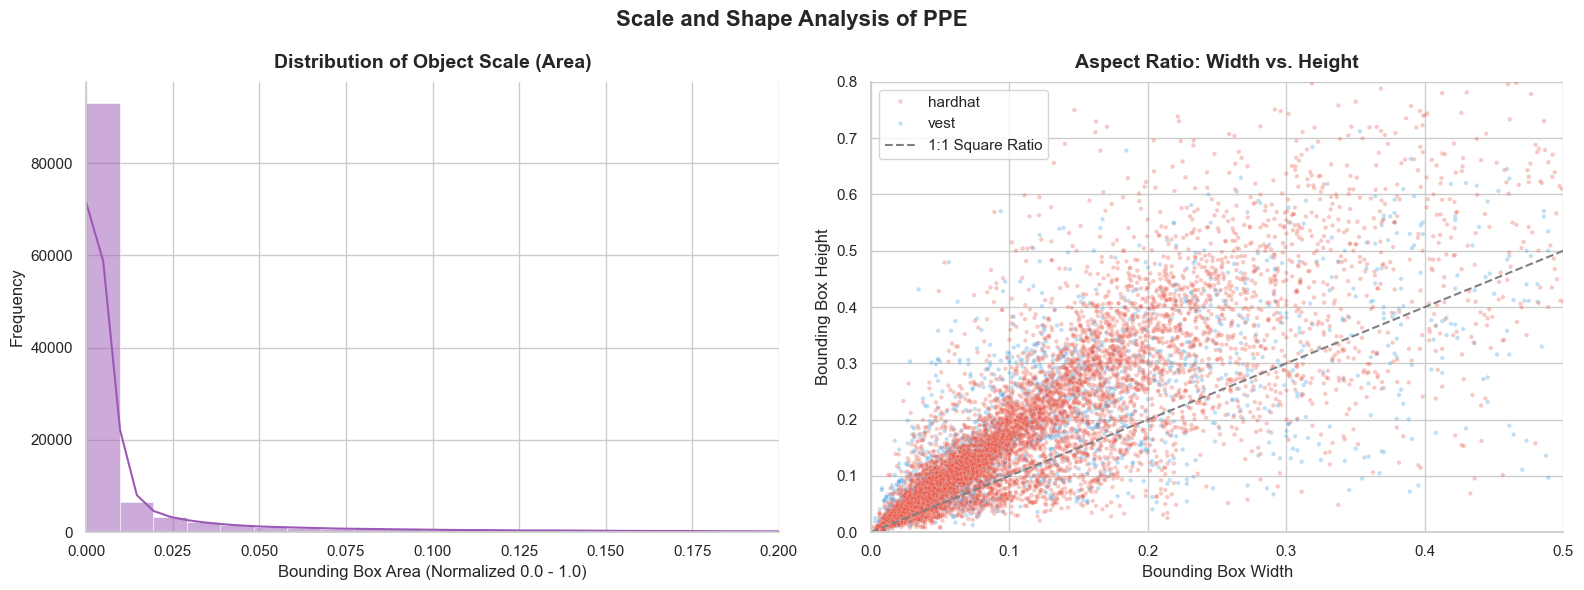

--- Bounding Box Scale Summary ---
Median Object Area:  0.0012 (0.12% of image)
90th Percentile Area: 0.0354 (3.54% of image)
Tiny Objects (< 1% area): 80.7% of dataset


In [7]:
# 5.0 Calculate Aspect Ratio
df['aspect_ratio'] = df['width'] / df['height']

# Create a 1x2 grid for scale and shape visualizations
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Bounding Box Area Distribution ---
# Since most objects are small, we limit the x-axis to 0.2 (20% of the image area) to see the detail
sns.histplot(
    data=df, 
    x='area', 
    bins=100, 
    kde=True, 
    color="#9b59b6", 
    ax=axes[0]
)
axes[0].set_title("Distribution of Object Scale (Area)", fontsize=14, weight='bold', pad=10)
axes[0].set_xlabel("Bounding Box Area (Normalized 0.0 - 1.0)")
axes[0].set_ylabel("Frequency")
axes[0].set_xlim(0, 0.2) # Zooming in on the smaller objects

# --- Plot 2: Width vs. Height (Aspect Ratio) ---
# Filter for just Hats and Vests to see their distinct shapes
hv_df = df[df['class_id'].isin([0, 2])]

sns.scatterplot(
    data=hv_df, 
    x='width', 
    y='height', 
    hue='class_name', 
    alpha=0.3, 
    s=10, # Marker size
    palette={"hardhat": "#e74c3c", "vest": "#3498db"},
    ax=axes[1]
)
# Draw a diagonal dashed line representing a perfect square (1:1 ratio)
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1.5, label='1:1 Square Ratio')

axes[1].set_title("Aspect Ratio: Width vs. Height", fontsize=14, weight='bold', pad=10)
axes[1].set_xlabel("Bounding Box Width")
axes[1].set_ylabel("Bounding Box Height")
axes[1].set_xlim(0, 0.5)
axes[1].set_ylim(0, 0.8)
axes[1].legend()

plt.suptitle("Scale and Shape Analysis of PPE", fontsize=16, weight='bold')
sns.despine()
plt.tight_layout()
plt.show()

# 5.1 Print Statistical Summary
print("--- Bounding Box Scale Summary ---")
print(f"Median Object Area:  {df['area'].median():.4f} ({(df['area'].median() * 100):.2f}% of image)")
print(f"90th Percentile Area: {df['area'].quantile(0.90):.4f} ({(df['area'].quantile(0.90) * 100):.2f}% of image)")
print(f"Tiny Objects (< 1% area): {(len(df[df['area'] < 0.01]) / len(df) * 100):.1f}% of dataset")